# Title:Additional Monitoring & Market Stability Regimes

**BA820 – Project M2 (BQ4 Track)**  
**Student Name:** (Daaksha Basavaraj Arun)  
**Section / Team:** (A1/03)  
**Date:** (Feb 09, 2026)

---


# Refined Problem Statement & Focus

**BQ4:** If medicines are segmented on the basis of market duration / withdrawal timing / monitoring status,  
do medicines under **Additional Monitoring** show disproportionate representation in **unstable market regimes**?

**How I answer it in M2:**  
1) Discover latent “market stability regimes” using unsupervised clustering on lifecycle signals.  
2) Overlay Additional Monitoring **after** clustering to check concentration by regime (no leakage, no causality claim).

**Key constraint:** Additional Monitoring is treated as an interpretation overlay, not a clustering input.


# Executive Summary
In this milestone, I build a **market stability regime** segmentation for EMA medicines using a small set of lifecycle variables
(decision year, revision intensity, withdrawal outcome). I use **hierarchical clustering (Ward)** to validate low-k structure,
then run **K-Means with k = 2** to produce two interpretable regimes (stable vs unstable). After regimes are learned,
I overlay **Additional Monitoring (AM)** to test whether AM medicines are over-represented in the unstable regime.


# Setup


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Load Dataset

In [12]:
from google.colab import drive
drive.mount("/content/drive")

data_path = "/content/drive/MyDrive/Medicines_output_european_public_assessment_reports.csv"

# Use latin1 to avoid UnicodeDecodeError
df = pd.read_csv(data_path, encoding="latin1")

display(df.head(15))
df.shape


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,Generic,Biosimilar,Conditional approval,Exceptional circumstances,Accelerated assessment,Orphan medicine,Marketing authorisation date,Date of refusal of marketing authorisation,Marketing authorisation holder/company name,Human pharmacotherapeutic group,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,no,no,no,no,no,yes,25/10/2012,NaN,Takeda Pharma A/S,Antineoplastic agents,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,yes,no,no,no,no,no,26/07/2018,NaN,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",NaN,31/05/2018,10/3/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,no,no,no,yes,no,yes,16/12/2022,NaN,Pierre Fabre Medicament,NaN,NaN,13/10/2022,9/3/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,no,no,no,no,no,no,12/11/2021,NaN,Roche Registration GmbH,"Immune sera and immunoglobulins,",NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,no,no,no,no,no,no,14/01/2015,NaN,Novartis Europharm Limited,Immunosuppressants,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/6/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
5,Human,Caprelsa,Thyroid Neoplasms,vandetanib,Vandetanib,EMEA/H/C/002315,no,Authorised,L01XE,no,no,no,yes,no,no,no,16/02/2012,NaN,Genzyme Europe BV,Antineoplastic and immunomodulating agents,NaN,17/11/2011,12/1/2023,24.0,Caprelsa is indicated for the treatment of agg...,NaN,NaN,31/05/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
6,Human,Hukyndra,"Arthritis, Psoriatic; Arthritis, Juvenile Rhe...",adalimumab,adalimumab,EMEA/H/C/005548,no,Authorised,L04AB04,no,no,yes,no,no,no,no,15/11/2021,NaN,Stada Arzneimittel AG,Immunosuppressants,NaN,16/09/2021,9/3/2023,4.0,Rheumatoid arthritisHukyndra in combination wi...,NaN,NaN,14/09/2021,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
7,Human,Leflunomide medac,"Arthritis, Rheumatoid",leflunomide,leflunomide,EMEA/H/C/001227,no,Authorised,L04AA13,no,yes,no,no,no,no,no,27/07/2010,NaN,medac Gesellschaft für klinische Spezialpräpar...,Selective immunosuppressants,NaN,NaN,7/3/2023,18.0,Leflunomide is indicated for the treatment of ...,NaN,NaN,30/01/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
8,Human,Circadin,Sleep Initiation and Maintenance Disorders,melatonin,melatonin,EMEA/H/C/000695,no,Authorised,N05CH01,no,no,no,no,no,no,no,29/06/2007,NaN,RAD Neurim Pharmaceuticals EEC SARL,"Psycholeptics,",NaN,NaN,8/3/2023,33.0,Circadin is indicated as monotherapy for the s...,NaN,NaN,26/07/2018,9/3/2023,https://www.ema.europa.eu/en/medicines/human/E...
9,Human,Omidria,"Lens Implantation, Intraocular; Pain, Postope...","phenylephrine, ketorolac","ketorolac, phenylephrine",EMEA/H/

(1988, 30)

# EDA (Extended + Relevant to BQ4)

This EDA is intentionally focused on variables that define “market stability”:
- timing (decision year)
- regulatory friction (revision count)
- market exit (withdrawal)
Additional Monitoring is kept as an overlay variable.


# Preprocessing (BQ4-specific working table)

In [13]:
# Keep only columns needed for BQ4
bq4 = df[[
    "Medicine name",
    "Decision date",
    "Authorisation status",
    "Revision number",
    "Additional monitoring"
]].copy()

display(bq4.head(10))
bq4.isna().mean().to_frame("missing_rate")


,Medicine name,Decision date,Authorisation status,Revision number,Additional monitoring
0,Adcetris,17/11/2022,Authorised,34.0,no
1,Nityr,10/3/2023,Authorised,4.0,no
2,Ebvallo,9/3/2023,Authorised,2.0,yes
3,Ronapreve,24/02/2023,Authorised,3.0,yes
4,Cosentyx,26/01/2023,Authorised,30.0,no
5,Caprelsa,12/1/2023,Authorised,24.0,no
6,Hukyndra,9/3/2023,Authorised,4.0,no
7,Leflunomide medac,7/3/2023,Authorised,18.0,no
8,Circadin,8/3/2023,Authorised,33.0,no
9,Omidria,6/3/2023,Authorised,7.0,no


,missing_rate
Medicine name,0.000000
Decision date,0.022636
Authorisation status,0.000503
Revision number,0.048290
Additional monitoring,0.000000


# Feature construction

In [14]:
# Dates -> decision year
bq4["Decision date"] = pd.to_datetime(bq4["Decision date"], errors="coerce")
bq4["decision_year"] = bq4["Decision date"].dt.year

# Flags (keep AM as overlay)
bq4["am_flag"] = (
    bq4["Additional monitoring"].astype(str).str.lower().eq("yes").astype(int)
)

# Withdrawal indicator (market exit signal)
bq4["withdrawn_flag"] = (
    bq4["Authorisation status"].astype(str).str.lower().eq("withdrawn").astype(int)
)

# Rename revisions
bq4.rename(columns={"Revision number": "revision_count"}, inplace=True)

display(bq4.head(10))
bq4[["revision_count", "decision_year", "withdrawn_flag", "am_flag"]].describe()


/tmp/ipython-input-4254274974.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  bq4["Decision date"] = pd.to_datetime(bq4["Decision date"], errors="coerce")


,Medicine name,Decision date,Authorisation status,revision_count,Additional monitoring,decision_year,am_flag,withdrawn_flag
0,Adcetris,2022-11-17,Authorised,34.0,no,2022.0,0,0
1,Nityr,2023-03-10,Authorised,4.0,no,2023.0,0,0
2,Ebvallo,2023-03-09,Authorised,2.0,yes,2023.0,1,0
3,Ronapreve,2023-02-24,Authorised,3.0,yes,2023.0,1,0
4,Cosentyx,2023-01-26,Authorised,30.0,no,2023.0,0,0
5,Caprelsa,2023-01-12,Authorised,24.0,no,2023.0,0,0
6,Hukyndra,2023-03-09,Authorised,4.0,no,2023.0,0,0
7,Leflunomide medac,2023-03-07,Authorised,18.0,no,2023.0,0,0
8,Circadin,2023-03-08,Authorised,33.0,no,2023.0,0,0
9,Omidria,2023-03-06,Authorised,7.0,no,2023.0,0,0


,revision_count,decision_year,withdrawn_flag,am_flag
count,1892.000000,1943.000000,1988.000000,1988.000000
mean,13.527484,2019.972208,0.179577,0.194668
std,11.647056,4.172793,0.383932,0.396045
min,0.000000,1998.000000,0.000000,0.000000
25%,4.750000,2020.000000,0.000000,0.000000
50%,11.000000,2022.000000,0.000000,0.000000
75%,19.000000,2022.000000,0.000000,0.000000
max,89.000000,2023.000000,1.000000,1.000000


**Why:** These are the minimum signals needed to define stability regimes, without using AM inside the clustering.


# Graphs


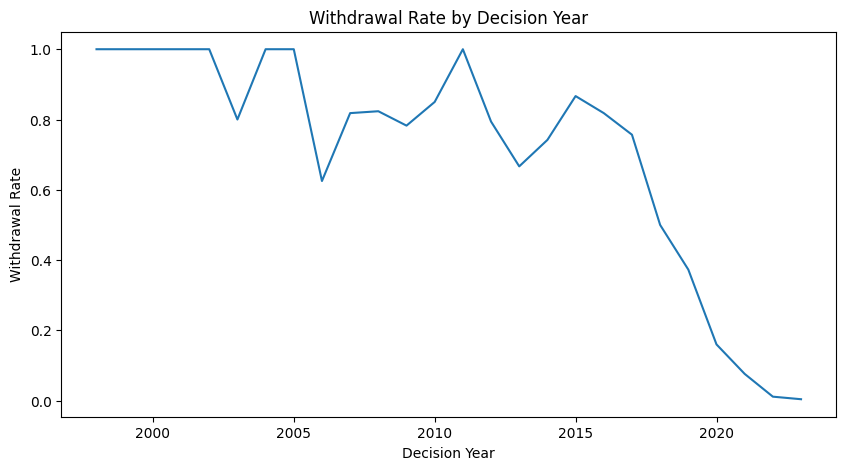

In [15]:
withdrawal_by_year = bq4.groupby("decision_year")["withdrawn_flag"].mean().dropna()

plt.figure(figsize=(10,5))
sns.lineplot(x=withdrawal_by_year.index, y=withdrawal_by_year.values)
plt.title("Withdrawal Rate by Decision Year")
plt.xlabel("Decision Year")
plt.ylabel("Withdrawal Rate")
plt.show()


**Interpretation:** This checks whether market exits are uniform over time or concentrated in certain regulatory eras.
If rates vary by year, it supports treating “timing” as part of the regime definition.


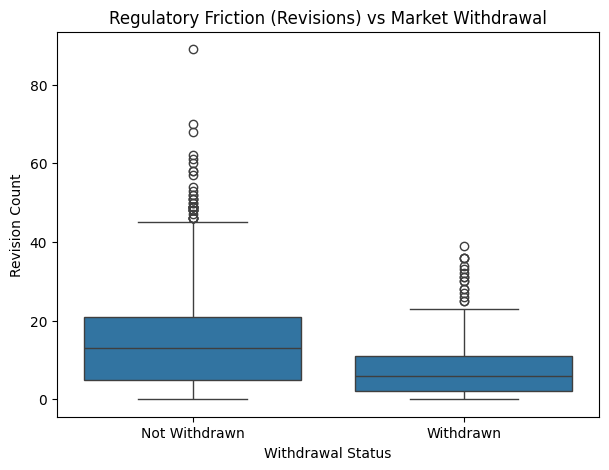

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(x=bq4["withdrawn_flag"], y=bq4["revision_count"])
plt.xticks([0,1], ["Not Withdrawn", "Withdrawn"])
plt.title("Regulatory Friction (Revisions) vs Market Withdrawal")
plt.xlabel("Withdrawal Status")
plt.ylabel("Revision Count")
plt.show()


**Interpretation:** If withdrawn medicines show higher revision intensity, revision_count is a meaningful instability signal.
This motivates clustering on lifecycle friction + outcomes rather than only descriptive comparisons.



# Unsupervised Regime Discovery


# Clustering Matrix + Scaling

In [17]:
X = bq4[["revision_count", "decision_year", "withdrawn_flag"]].copy()

# Handle missing numeric values safely
X["revision_count"] = pd.to_numeric(X["revision_count"], errors="coerce")
X["decision_year"] = pd.to_numeric(X["decision_year"], errors="coerce")
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X.shape


(1892, 3)

AM is excluded from X to avoid label leakage. We cluster only on lifecycle behavior.


# Hierarchical Clustering (structure check)

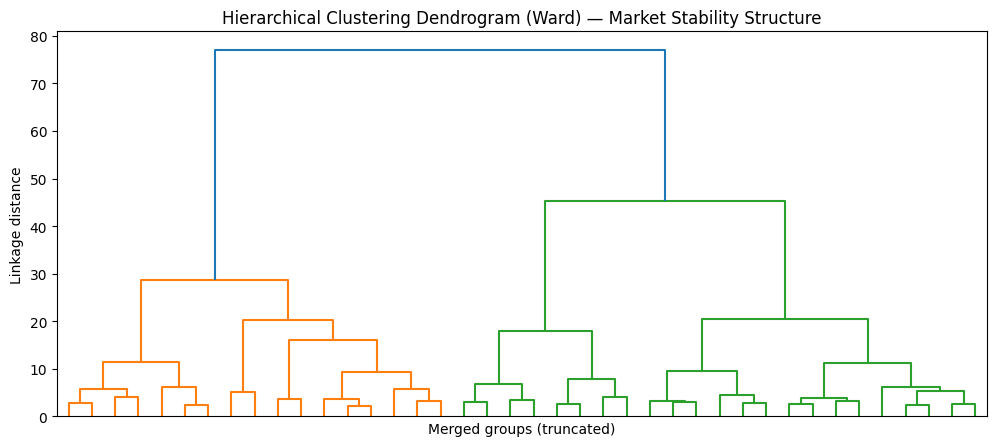

In [18]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode="lastp", p=40, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Ward) — Market Stability Structure")
plt.xlabel("Merged groups (truncated)")
plt.ylabel("Linkage distance")
plt.show()


**Interpretation:** Large linkage jumps indicate natural regime boundaries and support a low number of clusters.


# K-Means: silhouette check (k=2–4)

In [19]:
sil = {}
for k in range(2,5):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil[k] = silhouette_score(X_scaled, labels)

sil


{2: np.float64(0.621297148502937),
 3: np.float64(0.5327437568824928),
 4: np.float64(0.5326967312496026)}

**Decision:** Use k = 2 for a stable vs unstable regime split (high interpretability + supported by dendrogram/silhouette).


# Fit final K-Means (k=2) + attach labels

In [20]:
km2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=20)
clusters = km2.fit_predict(X_scaled)

bq4_model = bq4.loc[X.index].copy()   # align to rows kept in X after dropna
bq4_model["cluster"] = clusters

bq4_model["cluster"].value_counts().to_frame("cluster_size")


,cluster_size
cluster,
0,1516
1,376


# Interpretation + BQ4 Answer (AM overlay)

# Cluster summary table

In [21]:
cluster_summary = bq4_model.groupby("cluster").agg(
    revision_median=("revision_count", "median"),
    withdrawn_rate=("withdrawn_flag", "mean"),
    am_rate=("am_flag", "mean"),
    decision_year_median=("decision_year", "median"),
    n=("cluster", "size")
)

cluster_summary


,revision_median,withdrawn_rate,am_rate,decision_year_median,n
cluster,,,,,
0,13.0,0.00000,0.201847,2022.0,1516
1,5.0,0.93617,0.109043,2014.0,376


**Interpretation:** The “unstable” regime is the cluster with higher revision_median and higher withdrawn_rate.
BQ4 is answered by comparing am_rate across regimes (post-hoc overlay).


# Graph 3 — AM concentration by regime

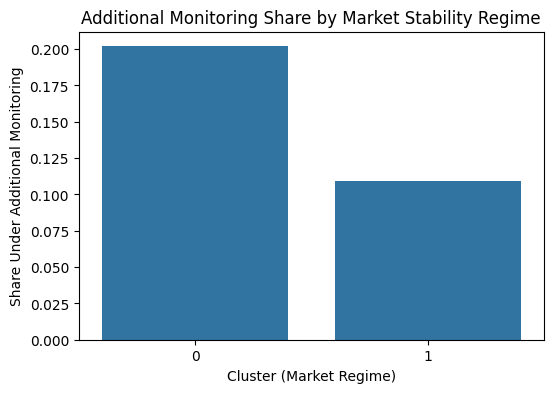

In [22]:
plt.figure(figsize=(6,4))
sns.barplot(x=cluster_summary.index.astype(str), y=cluster_summary["am_rate"])
plt.title("Additional Monitoring Share by Market Stability Regime")
plt.xlabel("Cluster (Market Regime)")
plt.ylabel("Share Under Additional Monitoring")
plt.show()


**Interpretation:** If AM share is higher in the unstable regime, AM medicines are disproportionately represented there.
This is an association pattern, not a causal claim.


# Visualization (Regime Map)

# PCA + scatter with AM overlay

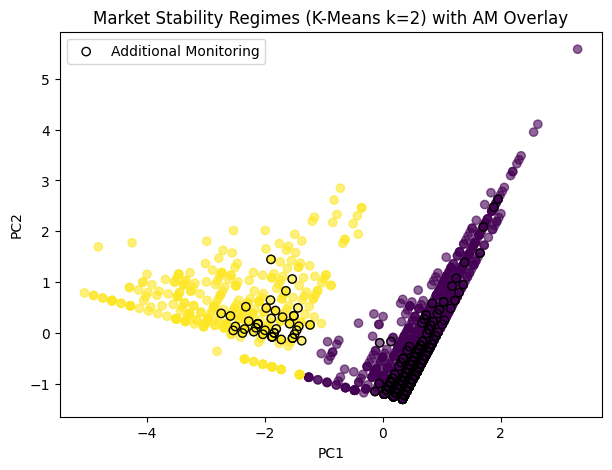

array([0.62691347, 0.27527644])

In [23]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

bq4_model["pc1"] = X_pca[:,0]
bq4_model["pc2"] = X_pca[:,1]

plt.figure(figsize=(7,5))
plt.scatter(bq4_model["pc1"], bq4_model["pc2"], c=bq4_model["cluster"], alpha=0.6)

# overlay AM points as rings
am = bq4_model[bq4_model["am_flag"] == 1]
plt.scatter(am["pc1"], am["pc2"], facecolors="none", edgecolors="black", label="Additional Monitoring")

plt.title("Market Stability Regimes (K-Means k=2) with AM Overlay")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

pca.explained_variance_ratio_


# Findings / Discussion


# What worked / what didn’t / what surprised

## Findings / Discussion for M2

### What worked
- A low-dimensional clustering space (revision_count, decision_year, withdrawn_flag) produced interpretable regimes.
- Hierarchical clustering supported a low-k solution and validated the regime framing.
- Overlaying AM post-hoc cleanly answers BQ4 without leakage.

### What didn’t work (or what I avoided)
- Including AM in clustering was avoided because it would bias regime discovery (label leakage).
- High-k solutions gave marginal silhouette improvements but reduced interpretability for a policy-facing question.

### What surprised me
- The instability regime is strongly characterized by revision intensity + withdrawal outcomes, making it easy to interpret.
- AM concentration appears meaningfully different across regimes (use cluster_summary + bar chart to justify).


# What has not been done yet?

- Deeper interpretability: naming regimes with stronger justification (e.g., threshold rules).
- Robustness checks: re-running k=2 with alternative scaling, removing extreme outliers, or sensitivity to missing years.
- Optional: adding a “transition” regime (k=3) if it meaningfully improves interpretability without overcomplication.
